# ROGII Wellbore Geology - Dense (MLP) Inference, Raw Scale

Load a trained Dense model that was trained on raw, unnormalized features and predict TVT for test wells.

**Runtime**: Kaggle GPU - **Author**: Samir Attrah


In [10]:
# !pip install --upgrade keras tensorflow


In [11]:
# Cell 1: Environment & Imports
import os
import warnings

os.environ["KERAS_BACKEND"] = "jax"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "true"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.7"

import keras
import numpy as np
import polars as pl

warnings.filterwarnings("ignore")
print(f"Keras: {keras.__version__}, Backend: {keras.backend.backend()}")


Keras: 3.12.0, Backend: jax


In [12]:
# Cell 2: Auto-detect dataset path
def find_data_dir():
    candidates = [
        "/kaggle/input/competitions/rogii-wellbore-geology-prediction",
        "/kaggle/input/rogii-wellbore-geology-prediction",
        "/home/samer/Documents/competitions/ROGII/dataset",
    ]
    for path in candidates:
        if os.path.isdir(path) and "test" in os.listdir(path):
            return path
    raise FileNotFoundError("Dataset not found.")


DATA_DIR = find_data_dir()


In [13]:
# Cell 3: Auto-detect model artifact
def find_model_path():
    """Find the exact raw-scale Dense model produced by 03_dense_training.ipynb."""
    expected_name = "dense_tvt_model.keras"
    search_roots = [
        "/kaggle/working",
        "/kaggle/input",
        "/home/samer/Documents/competitions/ROGII/outputs",
    ]

    matches = []
    for root in search_roots:
        if not os.path.isdir(root):
            continue

        direct = os.path.join(root, expected_name)
        if os.path.exists(direct):
            matches.append(direct)

        for dirpath, _, filenames in os.walk(root):
            if expected_name in filenames:
                path = os.path.join(dirpath, expected_name)
                if path not in matches:
                    matches.append(path)

    if not matches:
        raise FileNotFoundError(
            f"Could not find {expected_name}. Attach the output/model from "
            "notebooks/03_dense_training.ipynb to this Kaggle inference notebook. "
            "Do not use optimized_dense_model_denorm.keras for this raw-scale run."
        )

    print("Found raw-scale Dense model candidates:")
    for path in matches:
        print(f"  {path}")
    return matches[0]


MODEL_PATH = find_model_path()
print(f"Using model artifact: {MODEL_PATH}")


Found raw-scale Dense model candidates:
  /home/samer/Documents/competitions/ROGII/outputs/dense_tvt_model.keras
Using model artifact: /home/samer/Documents/competitions/ROGII/outputs/dense_tvt_model.keras


In [14]:
# Cell 4: Configuration
TEST_DATA_DIR = os.path.join(DATA_DIR, "test")
OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle") else "/home/samer/Documents/competitions/ROGII/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

CONFIG = {
    "data_dir": DATA_DIR,
    "test_data_dir": TEST_DATA_DIR,
    "model_path": MODEL_PATH,
    "submission_path": os.path.join(OUT_DIR, "submission.csv"),
}
FEATURE_COLS = ["MD", "X", "Y", "Z", "GR", "TVT_input"]

print(f"Data Dir: {DATA_DIR}")
print(f"Test Data Dir: {TEST_DATA_DIR}")
print(f"Model Path: {CONFIG['model_path']}")


Data Dir: /home/samer/Documents/competitions/ROGII/dataset
Test Data Dir: /home/samer/Documents/competitions/ROGII/dataset/test
Model Path: /home/samer/Documents/competitions/ROGII/outputs/dense_tvt_model.keras


In [15]:
# Cell 5: Load model
print("Loading model...")
model = keras.saving.load_model(CONFIG["model_path"])
print(f"Model loaded. Input shape: {model.input_shape}")


Loading model...
Model loaded. Input shape: (None, 6)


In [16]:
# Cell 6: Prediction Logic
def preprocess(df, feature_cols):
    """Preprocess one well exactly like the dense training notebook."""
    for col in feature_cols:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col)
                .interpolate()
                .fill_null(strategy="forward")
                .fill_null(strategy="backward")
                .fill_null(0.0)
            )
        else:
            df = df.with_columns(pl.lit(0.0).alias(col))
    return df


def get_submission_index(sample_sub):
    """Adds well_id and zero-based row_idx parsed from sample_submission ids."""
    return sample_sub.with_columns(
        [
            pl.col("id").str.extract(r"^(.+)_(\d+)$", 1).alias("well_id"),
            pl.col("id")
            .str.extract(r"^(.+)_(\d+)$", 2)
            .cast(pl.Int64)
            .alias("row_idx"),
        ]
    )


def predict_well(model, df):
    """Inference for the raw-scale Dense model trained in 03_dense_training.ipynb."""
    df = preprocess(df, FEATURE_COLS)
    X = df.select(FEATURE_COLS).to_numpy().astype(np.float32)
    return model.predict(X, batch_size=2048, verbose=0).ravel().astype(np.float32)


In [17]:
# Cell 7: Run Inference
sample_sub = get_submission_index(
    pl.read_csv(os.path.join(CONFIG["data_dir"], "sample_submission.csv"))
)

agg_sub = sample_sub.group_by("well_id").agg(
    pl.min("row_idx").alias("min_idx"),
    pl.max("row_idx").alias("max_idx"),
)
submission_windows = {
    row["well_id"]: list(range(row["min_idx"], row["max_idx"] + 1))
    for row in agg_sub.filter(
        pl.col("well_id").is_not_null()
        & pl.col("min_idx").is_not_null()
        & pl.col("max_idx").is_not_null()
    ).iter_rows(named=True)
}
test_ids = sorted(submission_windows)

all_preds = {}
for wid in test_ids:
    print(f"Predicting {wid}...")
    well_path = os.path.join(CONFIG["test_data_dir"], f"{wid}__horizontal_well.csv")
    if not os.path.exists(well_path):
        print(f"  Warning: File not found for {wid}")
        continue

    try:
        df = pl.read_csv(well_path, infer_schema_length=10000)
        all_preds[wid] = predict_well(model, df)
    except Exception as e:
        print(f"  Error predicting {wid}: {e}")

rows = []
missing = 0
for r in sample_sub.iter_rows(named=True):
    arr = all_preds.get(r["well_id"])
    if arr is None or r["row_idx"] is None or r["row_idx"] >= len(arr):
        val = 0.0
        missing += 1
    else:
        val = float(arr[r["row_idx"]])
    rows.append({"id": r["id"], "tvt": val})

if missing:
    print(f"Warning: {missing} submission rows were missing predictions and were filled with 0.0")

submission = pl.DataFrame(rows)
submission.write_csv(CONFIG["submission_path"])
print(f"Submission saved to {CONFIG['submission_path']}")
print(
    submission.select(
        pl.col("tvt").min().alias("min"),
        pl.col("tvt").max().alias("max"),
        pl.col("tvt").mean().alias("mean"),
    )
)


Predicting 000d7d20...
Predicting 00bbac68...
Predicting 00e12e8b...
Submission saved to /home/samer/Documents/competitions/ROGII/outputs/submission.csv
shape: (1, 3)
┌──────────────┬──────────────┬──────────────┐
│ min          ┆ max          ┆ mean         │
│ ---          ┆ ---          ┆ ---          │
│ f64          ┆ f64          ┆ f64          │
╞══════════════╪══════════════╪══════════════╡
│ 11607.042969 ┆ 12227.230469 ┆ 11907.921484 │
└──────────────┴──────────────┴──────────────┘


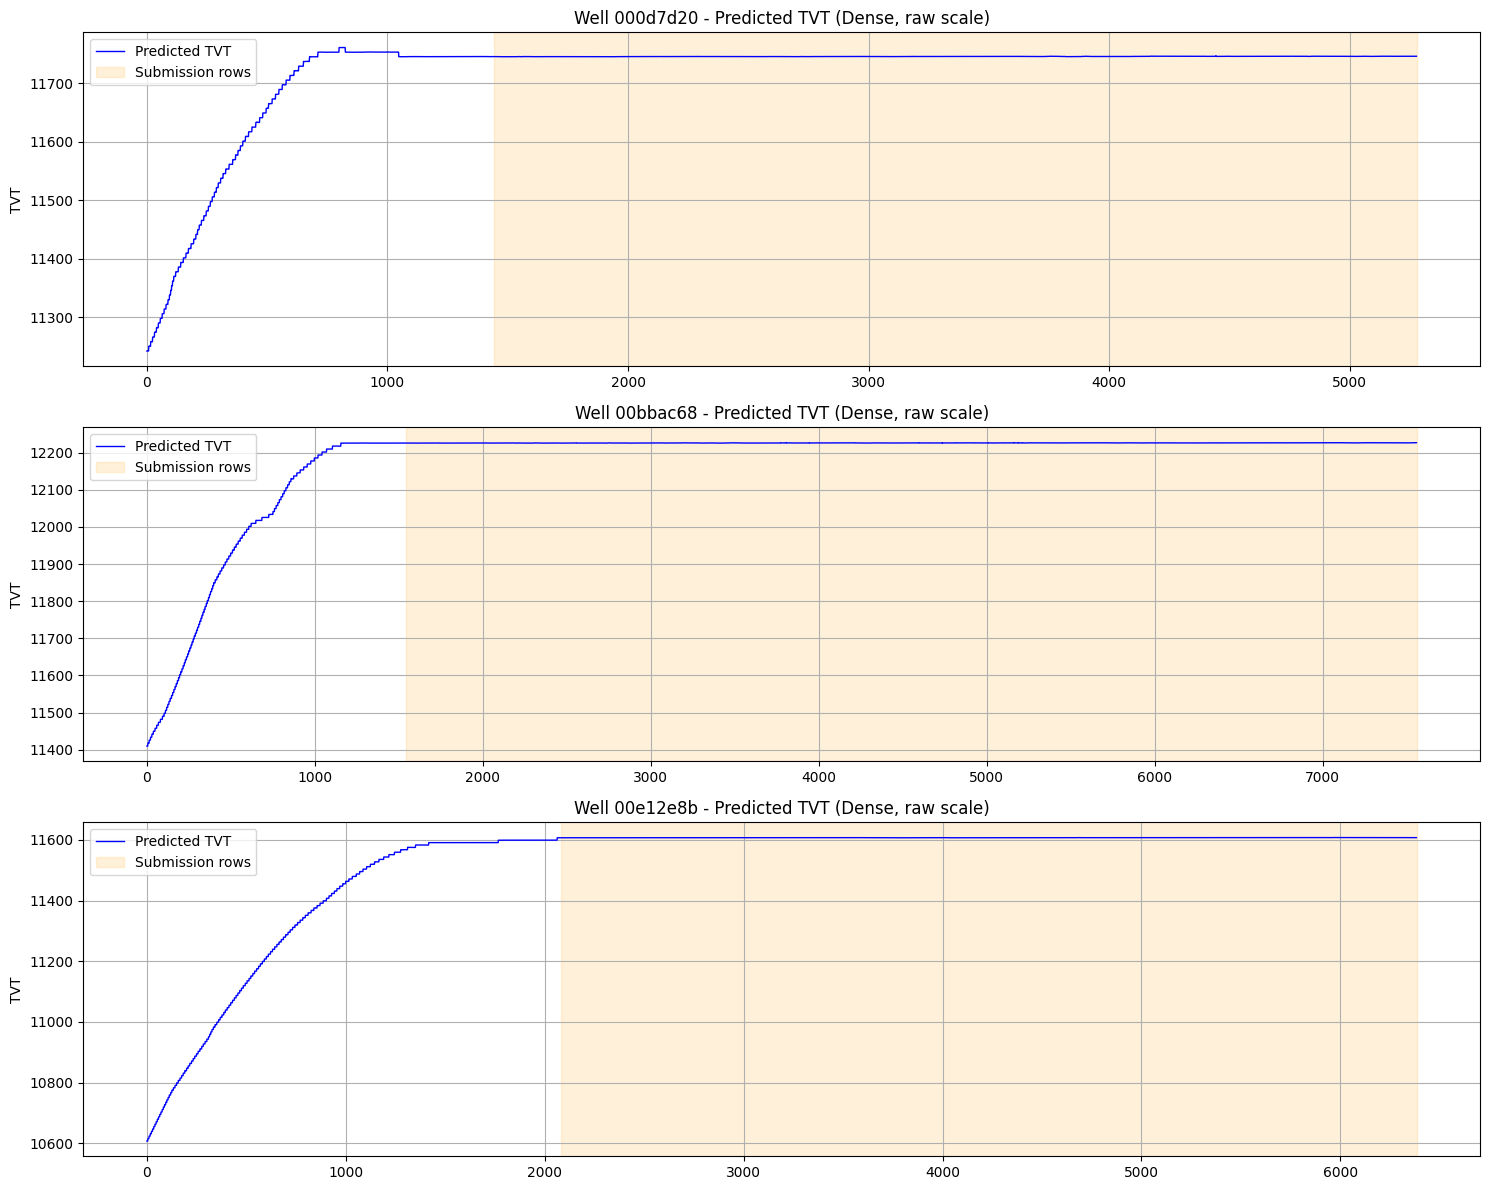

In [18]:
# Cell 8: Visualise Predictions
import matplotlib.pyplot as plt

ANALYTICS_DIR = "/kaggle/working" if os.path.isdir("/kaggle") else "../analytics"
os.makedirs(ANALYTICS_DIR, exist_ok=True)


def plot_predictions(all_preds, test_ids, submission_windows, max_plots=5):
    plot_ids = test_ids[:max_plots]
    n_wells = len(plot_ids)
    if n_wells == 0:
        return

    fig, axes = plt.subplots(n_wells, 1, figsize=(15, 4 * n_wells), sharex=False)
    if n_wells == 1:
        axes = [axes]

    for i, wid in enumerate(plot_ids):
        preds = all_preds[wid]
        axes[i].plot(preds, label="Predicted TVT", color="blue", lw=1)
        rows = submission_windows.get(wid, [])
        if rows:
            axes[i].axvspan(
                rows[0], rows[-1], color="orange", alpha=0.15, label="Submission rows"
            )
        axes[i].set_title(f"Well {wid} - Predicted TVT (Dense, raw scale)")
        axes[i].set_ylabel("TVT")
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(ANALYTICS_DIR, "test_predictions_plots_dense_denorm.png"))
    plt.show()


if "all_preds" in locals() and len(all_preds) > 0:
    plot_predictions(all_preds, test_ids, submission_windows)
